## Exploring the data

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
#/kaggle/input/datasets/shantguedekelian/
# Load one subject to start
raw = mne.io.read_raw_fif('preprocessed/S01_100hz_car.fif', preload=True)

# Look at the basic info
print(raw.info)

# How long is the recording and how many channels?
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Channel names: {raw.ch_names}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")

# Find the events (letter onsets)
events, event_id = mne.events_from_annotations(raw)
print(f"Events shape: {events.shape}")
print(f"First few events:\n{events[:10]}")
print(f"Event IDs: {event_id}")

Opening raw data file preprocessed/S01_100hz_car.fif...


C:\Users\Shant\AppData\Local\Temp\ipykernel_12508\1441440643.py:6: RuntimeWarning: This filename (preprocessed/S01_100hz_car.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif('preprocessed/S01_100hz_car.fif', preload=True)


    Range : 0 ... 604841 =      0.000 ...  6048.410 secs
Ready.
Reading 0 ... 604841  =      0.000 ...  6048.410 secs...
<Info | 11 non-empty values
 bads: []
 ch_names: EOG1, EOG2, EOG3, EOG4, AF7, AF3, AFz, AF4, AF8, F7, F5, F3, F1, ...
 chs: 4 EOG, 60 EEG, 2 misc
 custom_ref_applied: True
 dig: 63 items (3 Cardinal, 60 EEG)
 file_id: 4 items (dict)
 highpass: 0.3 Hz
 lowpass: 40.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 66
 projs: []
 sfreq: 100.0 Hz
>
Duration: 6048.4 seconds
Number of channels: 66
Channel names: ['EOG1', 'EOG2', 'EOG3', 'EOG4', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PPO1h', 'PPO2h', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'v_x', 'v_y']
Sampling frequen

In [2]:
import numpy as np
np.show_config()

{
  "Compilers": {
    "c": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35228",
      "commands": "cl.exe"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.2.5",
      "commands": "cython"
    },
    "c++": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35228",
      "commands": "cl.exe"
    }
  },
  "Machine Information": {
    "host": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    },
    "build": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    }
  },
  "Build Dependencies": {
    "blas": {
      "name": "blas",
      "found": true,
      "version": "3.9.0",
      "detection method": "pkgconfig",
      "include directory": "C:/Users/Shant/miniconda3/envs/myenv/Library/include",
      "lib directory": "C:/Users/Shant/miniconda3/envs/myenv/Library/lib",
      "openblas confi

c:\Users\Shant\miniconda3\envs\myenv\Lib\site-packages\numpy\__config__.py:155: UserWarning: Install `pyyaml` for better output
  warnings.warn("Install `pyyaml` for better output", stacklevel=1)


# EEG Dataset Summary — Subject S01

## Overview
This dataset comes from the paper *"Handwritten character classification from EEG through continuous kinematic decoding"* (Crell & Müller-Putz, 2024). It contains preprocessed EEG recordings from 20 subjects while they handwrote 10 different letters: **a, d, e, f, j, n, o, s, t, v**.

The goal is to classify which letter was written purely from the brain signals — no movement data required.

---

## Recording Basics

| Property | Value |
|---|---|
| Duration | ~6048 seconds (~1.7 hours) |
| Sampling Frequency | 100 Hz (1 sample every 0.01 seconds) |
| Total Channels | 66 |
| EEG Channels | 60 |
| EOG Channels | 4 |
| Misc Channels | 2 (hand kinematics) |
| Highpass Filter | 0.3 Hz |
| Lowpass Filter | 40 Hz |
| Reference | Common Average Reference (CAR) |

---

## Channel Types

### EEG Channels (60)
The brain signal electrodes placed across the scalp. Named by brain region:
- **F** (Frontal) — AF7, AF3, Fz, F1-F8 etc.
- **C** (Central) — C1, C3, Cz, C4 etc. — **most important for this task**, sit directly over the motor cortex which controls hand movement
- **P** (Parietal) — P1, Pz, P4 etc.
- **O** (Occipital) — O1, Oz, O2 etc.

### EOG Channels (4)
EOG1-EOG4 measure eye movements. Used during preprocessing to remove eye blink and eye movement artifacts from the EEG signal.

### Misc Channels (2) — v_x, v_y
The x and y hand position coordinates recorded from a motion capture system while the subject was writing. These are the **hand kinematics** used in the two-step classification approach described in the paper.

---

## Events & Annotations

There are 4474 total events in this recording. The key distinction is between two event types:

| Event Type | Example | Meaning |
|---|---|---|
| Letter events | `'a'`, `'d'` | When the letter cue appeared on screen |
| **Onset events** | `'a-onset'`, `'d-onset'` | When the participant **started writing** the letter |

For classification, we use the **onset events** — this is when the motor activity in the brain is most informative.

### Onset Event IDs
```python
onset_events = {
    'a-onset': 2,
    'd-onset': 4,
    'e-onset': 6,
    'f-onset': 12,
    'j-onset': 17,
    'n-onset': 19,
    'o-onset': 21,
    's-onset': 23,
    't-onset': 29,
    'v-onset': 31
}
```

Other annotations like `'fade in'`, `'fade out'`, `'fully in'`, `'e-round'`, `'s-write'` etc. are experiment control markers and are not used for classification.

---

## Preprocessing Already Applied
The data has been preprocessed (hence the filename `100hz_car.fif`):
- Notch filtered at 50 Hz
- Bandpass filtered between 0.3–40 Hz
- Eye artifacts removed using EOG channels and ICA
- Re-referenced to Common Average Reference (CAR)
- Downsampled to 100 Hz

---

## Next Steps
1. **Epoch** the data around each onset event (tmin=-0.2s, tmax=4.0s)
2. Extract **X** (EEG data) and **Y** (letter labels)
3. Train a classifier (EEGNet) to reproduce the direct classification results from the paper
4. Target accuracy: ~23.1% for all 10 letters, ~39% for the subset of 5 most discriminable letters (d, f, j, s, v)

In [3]:
onset_events = {
    'a-onset': 2,
    'd-onset': 4,
    'e-onset': 6,
    'f-onset': 12,
    'j-onset': 17,
    'n-onset': 19,
    'o-onset': 21,
    's-onset': 23,
    't-onset': 29,
    'v-onset': 31
}

epochs = mne.Epochs(
    raw,
    events,
    event_id=onset_events,
    tmin=-0.2,    # 200ms before onset
    tmax=4.0,     # 4 seconds after onset (matches paper)
    baseline=(-0.2, 0),
    preload=True
)

print(epochs)


# Get X and Y
X = epochs.get_data()  # shape: (n_trials, n_channels, n_timepoints)
Y = epochs.events[:, 2]  # event IDs = letter labels

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Unique labels: {np.unique(Y)}")

Not setting metadata
596 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 596 events and 421 original time points ...
7 bad epochs dropped
<Epochs | 589 events (all good), -0.2 – 4 s (baseline -0.2 – 0 s), ~124.9 MiB, data loaded,
 'a-onset': 60
 'd-onset': 59
 'e-onset': 57
 'f-onset': 59
 'j-onset': 58
 'n-onset': 59
 'o-onset': 60
 's-onset': 59
 't-onset': 59
 'v-onset': 59>
X shape: (589, 66, 421)
Y shape: (589,)
Unique labels: [ 2  4  6 12 17 19 21 23 29 31]


# Epoching Output Summary

## What is Epoching?
Epoching is the process of cutting the continuous EEG recording into smaller chunks (epochs) time-locked to a specific event — in our case, the moment the subject started writing each letter (`onset` events). Each epoch is one trial: one letter, one brain signal snapshot.

---

## Output Breakdown

### `596 matching events found`
MNE found 596 onset events across the full recording — roughly 60 per letter across 10 letters, which matches the paper's description of each letter being written approximately 60 times per subject.

---

### `Applying baseline correction (mode: mean)`
Before each epoch, MNE looks at the 200ms window before the onset (tmin=-0.2) and subtracts the average signal from that period. This removes any slow drifts in the signal and zeroes everything out relative to the pre-movement baseline — ensuring all epochs start from the same reference point regardless of any slow fluctuations in the raw signal.

---

### `7 bad epochs dropped`
MNE automatically detected and removed 7 epochs that were too noisy or corrupted. This is expected — the paper also mentions excluding bad trials during preprocessing. Final count: 596 → **589 usable epochs**.

---

### `589 events (all good)`
The final clean dataset has 589 epochs ready for classification.

---

### Per-letter trial counts
```
'a-onset': 60
'd-onset': 59
'e-onset': 57
'f-onset': 59
'j-onset': 58
'n-onset': 59
'o-onset': 60
's-onset': 59
't-onset': 59
'v-onset': 59
```
The dataset is well balanced — each letter has roughly 57–60 trials. This is important for classification since no single letter dominates the dataset, meaning the model won't be biased toward predicting one letter more than others.

---

### `-0.2 – 4 s (baseline -0.2 – 0 s)`
Each epoch spans from **200ms before** the writing onset to **4 seconds after**. The pre-onset window (-0.2 to 0s) is used for baseline correction. The 4 second post-onset window captures the full writing movement, since the paper found 99% of movements were completed within this window.

---

### `~124.9 MiB`
Total memory used to store all 589 epochs — about 125 megabytes. This is the cost of `preload=True`, which loads all data into RAM for faster access during modeling.

---

## Data Arrays

### `X shape: (589, 66, 421)`
This is the actual EEG data array — the input to the classifier:

| Dimension | Value | Meaning |
|---|---|---|
| Trials | 589 | One per writing attempt (epoch) |
| Channels | 66 | 60 EEG + 4 EOG + 2 kinematic (v_x, v_y) |
| Time points | 421 | 4.2 seconds × 100 Hz = 420, plus 1 = 421 |

Each trial is a **66 × 421 snapshot** of brain (and eye/hand) activity captured while the subject wrote one letter.

---

### `Y shape: (589,)`
One label per trial — 589 values each representing which letter was written in that trial.

---

### `Unique labels: [2, 4, 6, 12, 17, 19, 21, 23, 29, 31]`
These are the raw event IDs corresponding to the 10 onset events. Before feeding into a classifier, these should be remapped to clean integer labels 0–9:

```python
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
# Y_encoded is now [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] instead of [2, 4, 6, 12, 17, 19, 21, 23, 29, 31]
```

---

## Summary
| Property | Value |
|---|---|
| Total epochs | 589 |
| Letters | 10 (a, d, e, f, j, n, o, s, t, v) |
| Trials per letter | ~57–60 |
| Epoch window | -0.2s to 4.0s around onset |
| X shape | (589, 66, 421) |
| Y shape | (589,) |
| Chance accuracy | 10% (1 in 10 letters) |
| Target accuracy (paper) | ~23.1% for all 10 letters |

# Understanding the X Data Structure



## What is one trial?
Each trial is a **66 × 421 grid** of voltage measurements (in microvolts):
- **66 rows** — one per channel (electrode)
- **421 columns** — one per time point across the 4.2 second window

Every cell in the grid is a single voltage reading from one electrode at one moment in time.

---

## Visual Example — Trial #1 (subject wrote 'a')

```
         t=-0.2s  t=0.0s  t=0.01s  t=0.02s  ...  t=4.0s
                  ↑
              writing starts (onset)

EOG1   [  0.12,   0.11,   0.11,    0.13,   ...,   0.09  ]  ← eye movement
EOG2   [  0.05,   0.06,   0.06,    0.04,   ...,   0.07  ]  ← eye movement
EOG3   [  0.03,   0.02,   0.03,    0.02,   ...,   0.04  ]  ← eye movement
EOG4   [  0.01,   0.01,   0.02,    0.01,   ...,   0.02  ]  ← eye movement
AF7    [  0.45,   0.43,   0.44,    0.46,   ...,   0.41  ]  ← frontal
AF3    [  0.32,   0.31,   0.33,    0.30,   ...,   0.29  ]  ← frontal
...
C3     [  1.23,   1.31,   1.35,    1.28,   ...,   0.98  ]  ← motor cortex ⭐
Cz     [  1.45,   1.42,   1.48,    1.50,   ...,   1.21  ]  ← motor cortex ⭐
C4     [  1.10,   1.15,   1.18,    1.12,   ...,   0.95  ]  ← motor cortex ⭐
...
O1     [  0.22,   0.21,   0.23,    0.20,   ...,   0.19  ]  ← occipital
Oz     [  0.18,   0.17,   0.19,    0.16,   ...,   0.15  ]  ← occipital
O2     [  0.20,   0.19,   0.21,    0.18,   ...,   0.17  ]  ← occipital
v_x    [  0.00,   0.00,   0.01,    0.03,   ...,   0.87  ]  ← hand x position
v_y    [  0.00,   0.00,   0.00,    0.02,   ...,   0.54  ]  ← hand y position

Label (Y): 2  →  'a-onset'
```

> ⭐ The central channels (C3, Cz, C4) sit directly over the **motor cortex** — the part of the brain that controls hand movement. These channels are expected to carry the most useful signal for classifying which letter was written.

---

## How to access specific parts of X

```python
# Get the first trial (all channels, all time points)
trial_1 = X[0]               # shape: (66, 421)

# Get the first channel of the first trial (one electrode over time)
channel_1_trial_1 = X[0, 0]  # shape: (421,)

# Get all trials for just the Cz channel (index 31)
cz_all_trials = X[:, 31, :]  # shape: (589, 421)

# Get a single voltage measurement (trial 1, channel 1, time point 1)
single_value = X[0, 0, 0]    # one float (microvolts)
```

---

## The full picture

```
X[0]   →  trial 1  →  66 × 421 grid  →  label: 'a-onset'
X[1]   →  trial 2  →  66 × 421 grid  →  label: 'd-onset'
X[2]   →  trial 3  →  66 × 421 grid  →  label: 'a-onset'
...
X[588] →  trial 589 → 66 × 421 grid  →  label: 'v-onset'
```

The classifier looks at each 66 × 421 grid and tries to predict which of the 10 letters was being written — purely from the brain (and eye/hand) signals.

---

## Key numbers to remember

| Property | Value |
|---|---|
| Chance accuracy | 10% (random guess across 10 letters) |
| Target accuracy (paper) | ~23.1% for all 10 letters |
| Target accuracy (best 5 letters) | ~39.0% for subset d, f, j, s, v |
| Most informative channels | C3, Cz, C4 (motor cortex) |
| Time window | -0.2s to 4.0s around writing onset |

---
---
# Visualizing the data

Using matplotlib as 2D backend.


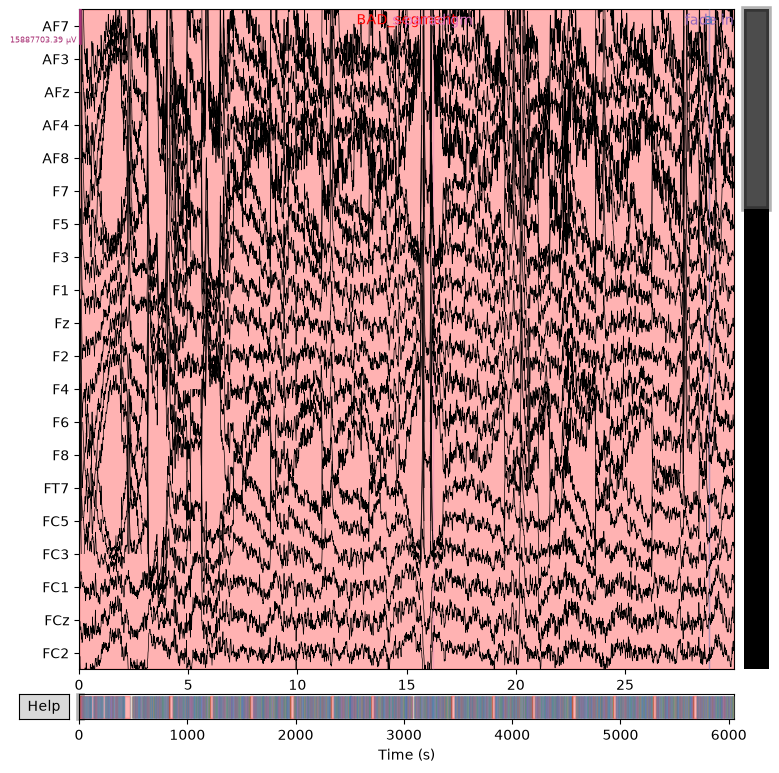

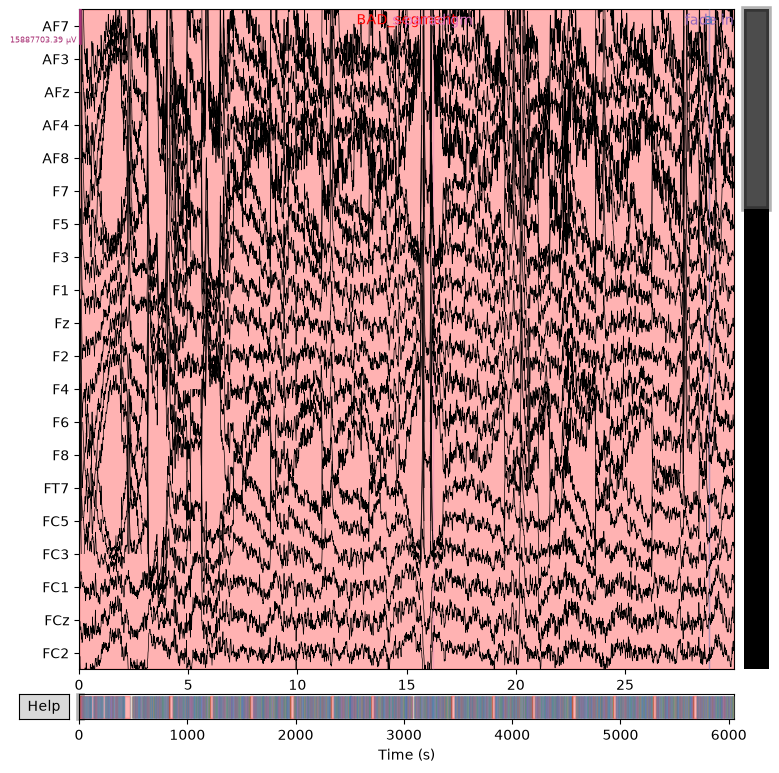

In [3]:
# Plot a sample of the raw continuous EEG signal
# This shows you what brain signals actually look like over time
raw.plot(
    duration=30,        # show 30 seconds at a time
    n_channels=20,      # show 20 channels at once
    scalings='auto',    # auto scale the amplitude
    title='Raw EEG Signal — S01'
)

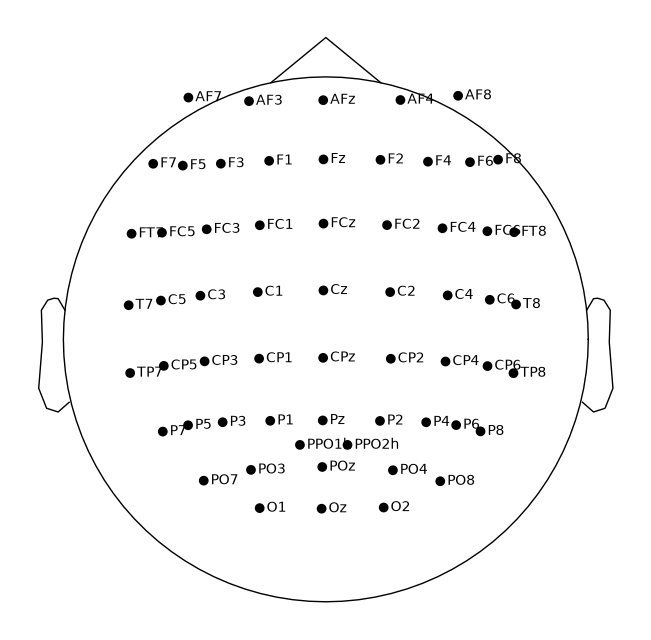

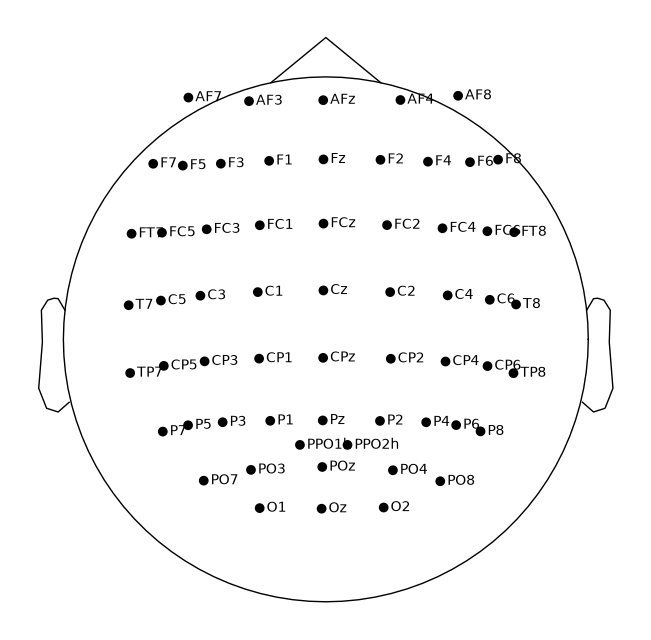

In [4]:
# Shows where each electrode sits on the scalp

# Coverage — electrodes should be spread across the whole scalp, front to back and left to right
# Central cluster — there should be a clear cluster of electrodes in the middle of the head 
#       (C3, Cz, C4 etc.) — these are the motor cortex channels most important for your task
# Symmetry — the layout should look roughly symmetrical left to right
# Labels — you should be able to see the channel names and confirm the central ones are there

raw.plot_sensors(show_names=True, title='Electrode Locations')

Setting 87982 of 604842 (14.55%) samples to NaN, retaining 516860 (85.45%) samples.
Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).


c:\Users\Shant\miniconda3\envs\myenv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


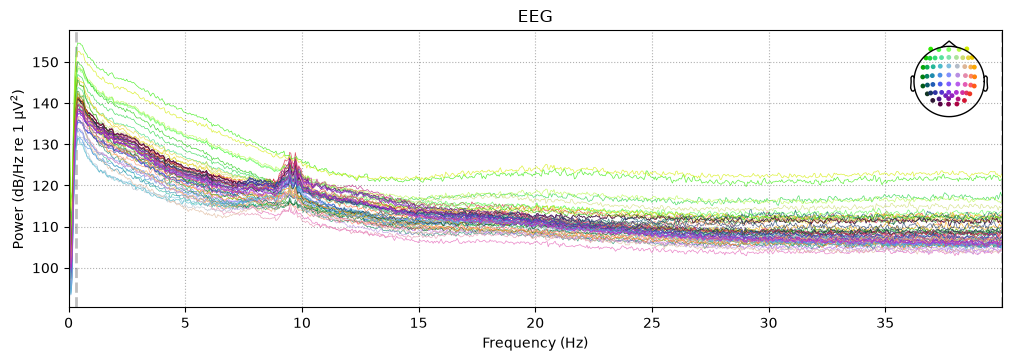

In [5]:
# This shows you the frequency content of the EEG
# You should see a clear peak around 10 Hz (alpha waves — common in EEG)

# Overall shape — should slope downward from left to right, meaning lower frequencies have more power than higher ones. 
#       This is called the 1/f pattern and is a hallmark of healthy EEG
# Alpha peak — look for a small bump around 8–13 Hz. This is the alpha wave, the most prominent brain rhythm 
#       and a sign the data is real EEG and not just noise
# 50/60 Hz noise — since the data is filtered at 40 Hz you shouldn't see anything above that, which is good

raw.compute_psd(fmax=40).plot(
    picks='eeg'        # only EEG channels
    
)

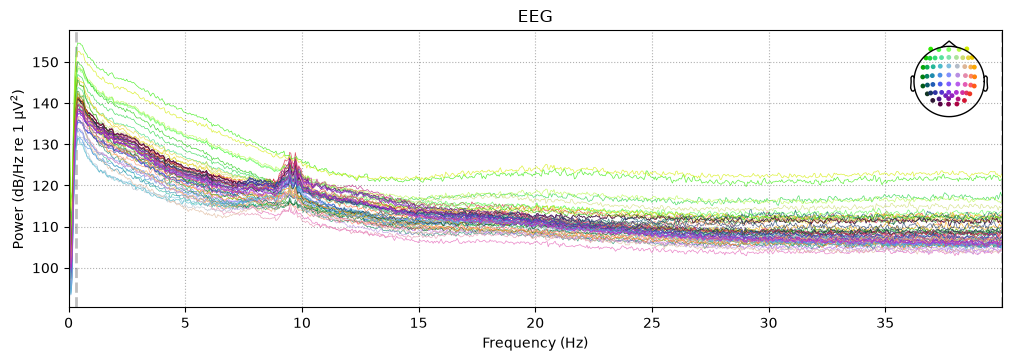

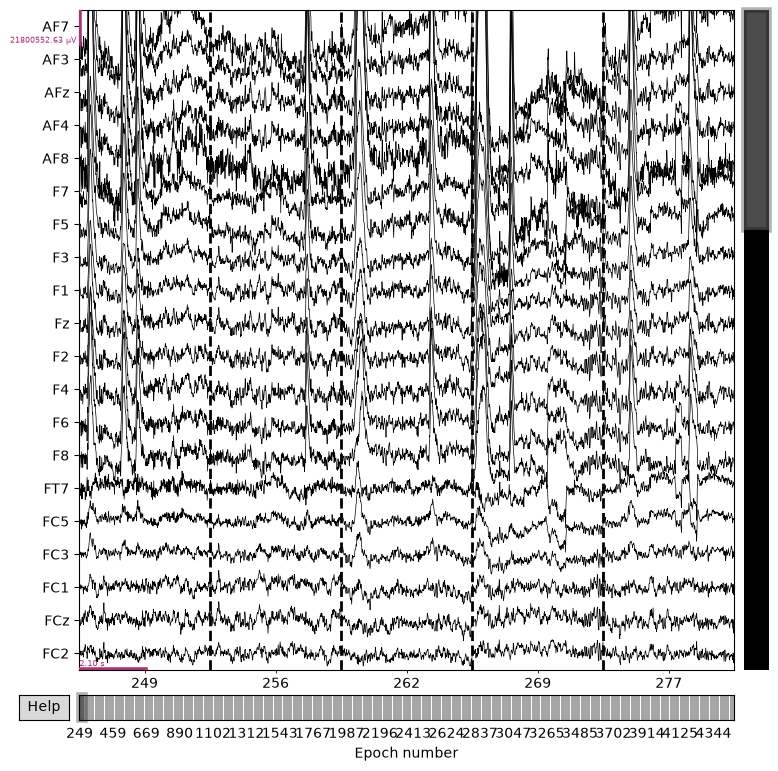

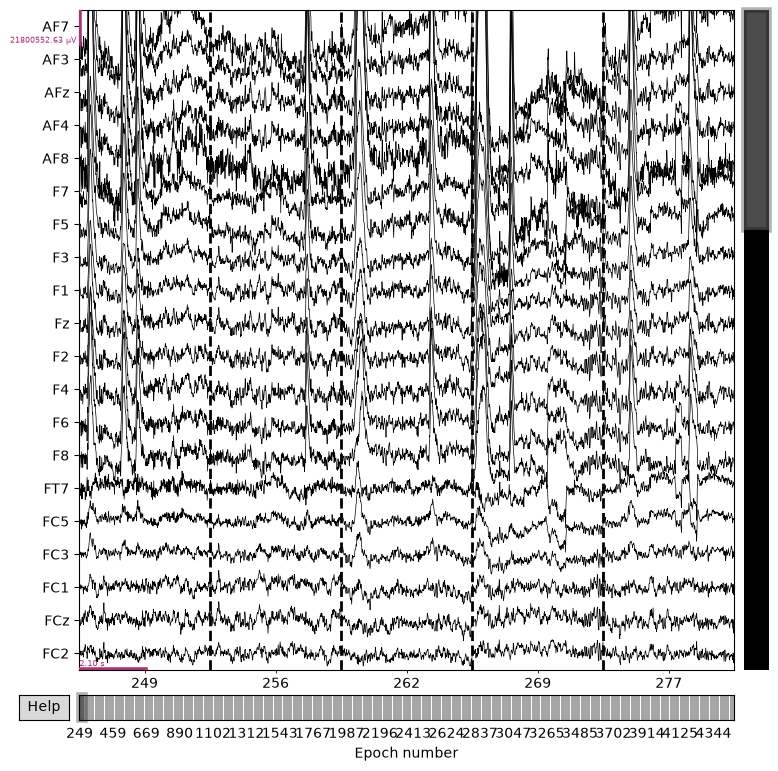

In [6]:
# This lets you scroll through individual trials
# You can see the brain activity for each letter writing attempt
epochs.plot(
    n_epochs=5,          # show 5 epochs at a time
    n_channels=20,       # show 20 channels
    scalings='auto',
    title='Individual Epochs'
)

Not setting metadata


589 matching events found
No baseline correction applied
0 projection items activated


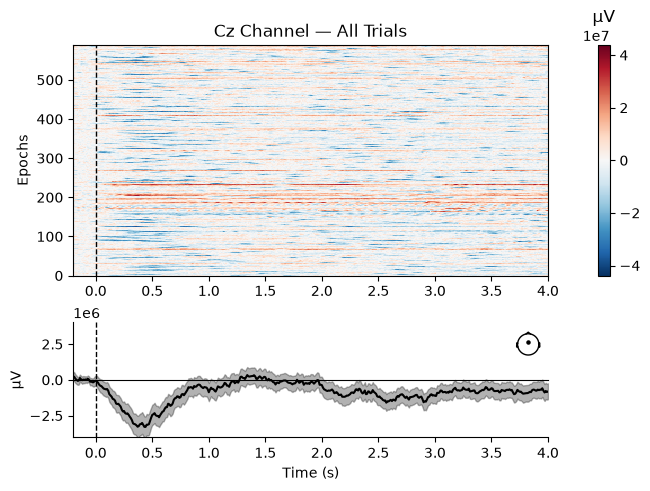

In [7]:
# This is one of the most useful visualizations
# Each row is one trial, x-axis is time, color is signal amplitude
# You can visually see if there are consistent patterns across trials
fig = epochs.plot_image(
    picks=['Cz'],        # look at Cz — sits right over motor cortex
    title='Cz Channel — All Trials'
)

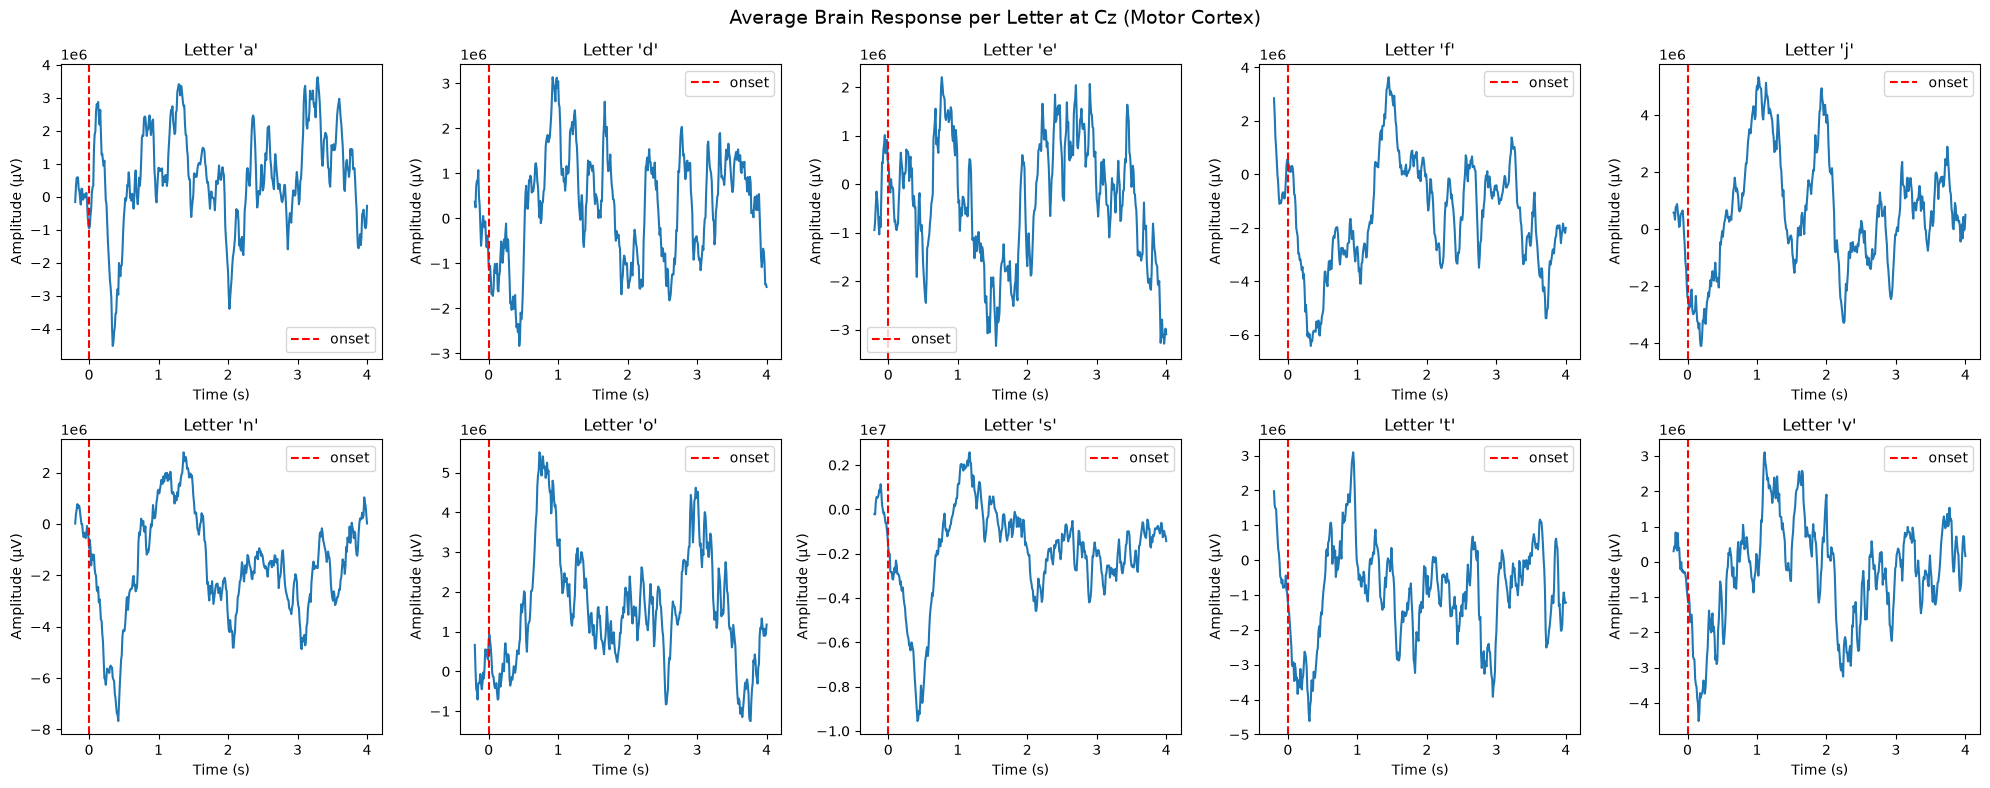

In [8]:
# Average all trials of the same letter together
# This cancels out random noise and reveals the consistent brain response
# This is called an "evoked response" or "ERP"
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

letters = ['a-onset', 'd-onset', 'e-onset', 'f-onset', 'j-onset',
           'n-onset', 'o-onset', 's-onset', 't-onset', 'v-onset']

for i, letter in enumerate(letters):
    evoked = epochs[letter].average()
    # Plot just the Cz channel for each letter
    cz_idx = epochs.ch_names.index('Cz')
    times = epochs.times
    axes[i].plot(times, evoked.data[cz_idx] * 1e6)  # convert to microvolts
    axes[i].axvline(x=0, color='red', linestyle='--', label='onset')
    axes[i].set_title(f"Letter '{letter.split('-')[0]}'")
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude (µV)')
    axes[i].legend()

plt.suptitle('Average Brain Response per Letter at Cz (Motor Cortex)', 
             fontsize=14)
plt.tight_layout()
plt.show()

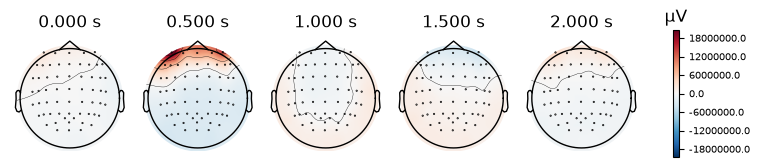

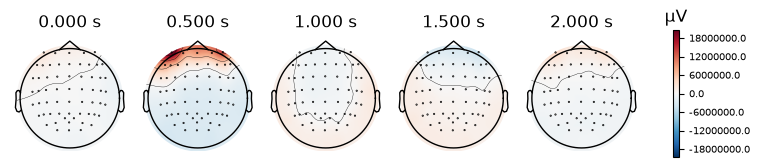

In [9]:
# This shows where on the scalp the activity is strongest
# at the moment of writing onset
# You should see strongest activity over the central/motor areas

# Average across all letters
evoked_all = epochs.average()

# Plot topomaps at different time points
evoked_all.plot_topomap(
    times=[0.0, 0.5, 1.0, 1.5, 2.0]  # at these seconds after onset
    
)

---
---
# Modelling

## First Baseline Models

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Step 1 — Drop EOG and kinematic channels, keep only 60 EEG channels
# EOG channels are first 4, v_x and v_y are last 2
X_eeg = X[:, 4:64, :]  # shape: (589, 60, 421)
print(f"X_eeg shape: {X_eeg.shape}")

# Step 2 — Encode labels to 0-9
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
print(f"Y_encoded unique labels: {np.unique(Y_encoded)}")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_eeg shape: (589, 60, 421)
Y_encoded unique labels: [0 1 2 3 4 5 6 7 8 9]
Label mapping: {np.int64(2): np.int64(0), np.int64(4): np.int64(1), np.int64(6): np.int64(2), np.int64(12): np.int64(3), np.int64(17): np.int64(4), np.int64(19): np.int64(5), np.int64(21): np.int64(6), np.int64(23): np.int64(7), np.int64(29): np.int64(8), np.int64(31): np.int64(9)}


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 1 — trim to 2 seconds post onset (same as before)
sfreq = 100
tmin_idx = int(0.2 * sfreq)
tmax_idx = int(2.2 * sfreq)
X_trimmed = X_eeg[:, :, tmin_idx:tmax_idx]  # (589, 60, 200)

# Step 2 — normalize
X_norm = X_trimmed / (np.std(X_trimmed) + 1e-8)

# Step 3 — flatten to 2D for sklearn
X_flat = X_norm.reshape(X_norm.shape[0], -1)  # (589, 12000)

# Step 4 — encode labels
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

print(f"X_flat shape: {X_flat.shape}")
print(f"Y_encoded shape: {Y_encoded.shape}")
print(f"Chance level: {1/len(np.unique(Y_encoded))*100:.1f}%")

X_flat shape: (589, 12000)
Y_encoded shape: (589,)
Chance level: 10.0%


In [6]:
# PCA + LDA
pipeline_lda = Pipeline([
    ('pca', PCA(n_components=50)),
    ('lda', LinearDiscriminantAnalysis())
])

# PCA + SVM
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# PCA + Random Forest
pipeline_rf = Pipeline([
    ('pca', PCA(n_components=50)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

print("Pipelines defined successfully")

Pipelines defined successfully


In [7]:
# 2x repeated 5-fold CV matching the paper
skf = StratifiedKFold(n_splits=5, shuffle=False)

def run_cv(pipeline, X, Y, n_repeats=2, n_splits=5):
    all_accs = []
    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, 
                              random_state=repeat)
        for train_idx, test_idx in skf.split(X, Y):
            X_train, X_test = X[train_idx], X[test_idx]
            Y_train, Y_test = Y[train_idx], Y[test_idx]
            
            pipeline.fit(X_train, Y_train)
            preds = pipeline.predict(X_test)
            all_accs.append(accuracy_score(Y_test, preds))
    
    mean_acc = np.mean(all_accs) * 100
    std_acc = np.std(all_accs) * 100
    return mean_acc, std_acc

print("Running PCA + LDA...")
lda_mean, lda_std = run_cv(pipeline_lda, X_flat, Y_encoded)
print(f"  LDA: {lda_mean:.1f}% ± {lda_std:.1f}%")

print("Running PCA + SVM...")
svm_mean, svm_std = run_cv(pipeline_svm, X_flat, Y_encoded)
print(f"  SVM: {svm_mean:.1f}% ± {svm_std:.1f}%")

print("Running PCA + Random Forest...")
rf_mean, rf_std = run_cv(pipeline_rf, X_flat, Y_encoded)
print(f"  RF:  {rf_mean:.1f}% ± {rf_std:.1f}%")

Running PCA + LDA...
  LDA: 10.7% ± 3.0%
Running PCA + SVM...
  SVM: 12.4% ± 1.8%
Running PCA + Random Forest...
  RF:  9.6% ± 2.4%


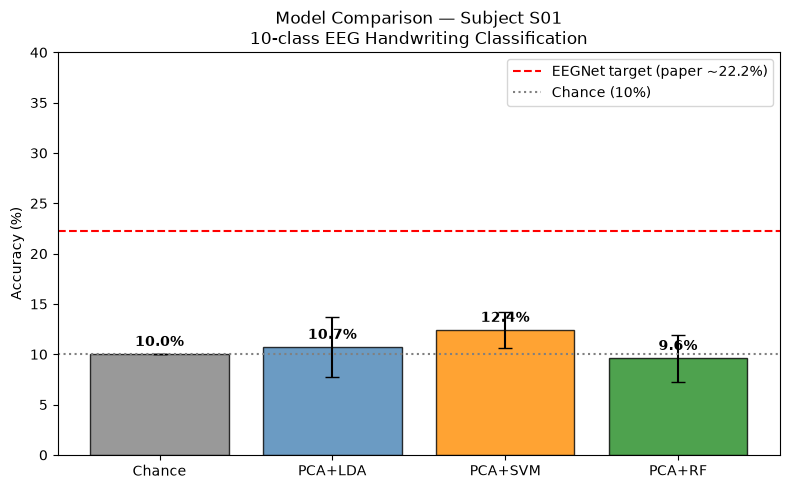


Summary:
Chance:  10.0%
PCA+LDA: 10.7% ± 3.0%
PCA+SVM: 12.4% ± 1.8%
PCA+RF:  9.6% ± 2.4%
EEGNet target (paper): ~22.2%


In [8]:
models = ['Chance', 'PCA+LDA', 'PCA+SVM', 'PCA+RF']
means  = [10.0,     lda_mean,  svm_mean,  rf_mean]
stds   = [0,        lda_std,   svm_std,   rf_std]
colors = ['gray',   'steelblue', 'darkorange', 'forestgreen']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, means, yerr=stds, capsize=5,
              color=colors, alpha=0.8, edgecolor='black')

# Add paper target line
ax.axhline(y=22.2, color='red', linestyle='--', 
           label='EEGNet target (paper ~22.2%)')

# Add chance line
ax.axhline(y=10, color='gray', linestyle=':', 
           label='Chance (10%)')

# Add value labels on bars
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.5,
            f'{mean:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — Subject S01\n10-class EEG Handwriting Classification')
ax.legend()
ax.set_ylim(0, 40)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"Chance:  10.0%")
print(f"PCA+LDA: {lda_mean:.1f}% ± {lda_std:.1f}%")
print(f"PCA+SVM: {svm_mean:.1f}% ± {svm_std:.1f}%")
print(f"PCA+RF:  {rf_mean:.1f}% ± {rf_std:.1f}%")
print(f"EEGNet target (paper): ~22.2%")

## EEGNet - Replicating Research Paper's Results

In [16]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q


In [5]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
# # Test a simple GPU operation to confirm it actually works
x = torch.tensor([1.0, 2.0, 3.0]).cuda()
print(x)  # if this prints without error, GPU is working

12.6
True
NVIDIA GeForce RTX 3060 Ti
tensor([1., 2., 3.], device='cuda:0')


In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Step 1 — Drop EOG and kinematic channels, keep only 60 EEG channels
# EOG channels are first 4, v_x and v_y are last 2
X_eeg = X[:, 4:64, :]  # shape: (589, 60, 421)
print(f"X_eeg shape: {X_eeg.shape}")

# Step 2 — Encode labels to 0-9
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
print(f"Y_encoded unique labels: {np.unique(Y_encoded)}")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_eeg shape: (589, 60, 421)
Y_encoded unique labels: [0 1 2 3 4 5 6 7 8 9]
Label mapping: {np.int64(2): np.int64(0), np.int64(4): np.int64(1), np.int64(6): np.int64(2), np.int64(12): np.int64(3), np.int64(17): np.int64(4), np.int64(19): np.int64(5), np.int64(21): np.int64(6), np.int64(23): np.int64(7), np.int64(29): np.int64(8), np.int64(31): np.int64(9)}


### Defining EEG architecture

In [19]:
class EEGNet(nn.Module):
    def __init__(self, n_classes=10, n_channels=60, n_timepoints=421,
                 F1=8, D=2, F2=16, dropout=0.5):
        super(EEGNet, self).__init__()
        
        # Block 1 — Temporal convolution
        # Learns frequency-specific features across time
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1)
        )
        
        # Block 2 — Depthwise spatial convolution
        # Learns spatial filters (which channels/electrodes matter)
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )
        
        # Block 3 — Separable convolution
        # Combines temporal and spatial features
        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16),
                      padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )
        
        # Calculate the size of flattened features
        self.flatten_size = self._get_flatten_size(n_channels, n_timepoints, F1, D, F2)
        
        # Final classifier
        self.classifier = nn.Linear(self.flatten_size, n_classes)
    
    def _get_flatten_size(self, n_channels, n_timepoints, F1, D, F2):
        # Run a dummy forward pass to calculate flatten size
        x = torch.zeros(1, 1, n_channels, n_timepoints)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x.view(1, -1).shape[1]
    
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x

### Training and Cross Validation loop

In [20]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()

def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(Y_batch.numpy())
    return accuracy_score(all_labels, all_preds)

def run_cross_validation(X, Y, n_splits=5, n_repeats=2, n_epochs=300, 
                          batch_size=32, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    all_accuracies = []
    
    for repeat in range(n_repeats):
        print(f"\n--- Repeat {repeat + 1}/{n_repeats} ---")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, 
                               random_state=repeat)
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, Y)):
            print(f"  Fold {fold + 1}/{n_splits}", end='')
            
            # Split data
            X_train, X_test = X[train_idx], X[test_idx]
            Y_train, Y_test = Y[train_idx], Y[test_idx]
            
            # Convert to tensors — EEGNet expects (batch, 1, channels, timepoints)
            X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
            X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
            Y_train_t = torch.LongTensor(Y_train)
            Y_test_t = torch.LongTensor(Y_test)
            
            # Create data loaders
            train_ds = TensorDataset(X_train_t, Y_train_t)
            test_ds = TensorDataset(X_test_t, Y_test_t)
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            test_loader = DataLoader(test_ds, batch_size=batch_size)
            
            # Initialize model
            model = EEGNet(n_classes=10, n_channels=60, 
                          n_timepoints=421).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            
            # Train
            for epoch in range(n_epochs):
                train_model(model, train_loader, criterion, optimizer, device)
            
            # Evaluate
            acc = evaluate_model(model, test_loader, device)
            all_accuracies.append(acc)
            print(f" — Accuracy: {acc*100:.1f}%")
    
    print(f"\n{'='*40}")
    print(f"Mean Accuracy: {np.mean(all_accuracies)*100:.1f}%")
    print(f"Std Accuracy:  {np.std(all_accuracies)*100:.1f}%")
    print(f"Target (paper): ~22.2%")
    print(f"Chance level:   10.0%")
    return all_accuracies

### Run it

In [ ]:
# Normalize X (important for neural networks)
device = torch.device('cpu')
print(f"Using device: {device}")
X_norm = X_eeg / (np.std(X_eeg) + 1e-8)

# Run cross validation
accuracies = run_cross_validation(X_norm, Y_encoded, 
                                   n_splits=5, 
                                   n_repeats=2,
                                   n_epochs=30)

Using device: cpu
Using device: cpu

--- Repeat 1/2 ---
  Fold 1/5

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ── 1. Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── 2. Drop EOG and kinematic channels, keep only 60 EEG channels
X_eeg = X[:, 4:64, :]
print(f"X_eeg shape: {X_eeg.shape}")

# ── 3. Trim to 2 seconds post onset (paper's optimal window)
sfreq = 100
tmin_idx = int(0.2 * sfreq)   # skip 200ms baseline
tmax_idx = int(2.2 * sfreq)   # 2 seconds post onset
X_trimmed = X_eeg[:, :, tmin_idx:tmax_idx]
print(f"X_trimmed shape: {X_trimmed.shape}")  # (589, 60, 200)

# ── 4. Normalize
X_norm = X_trimmed / (np.std(X_trimmed) + 1e-8)

# ── 5. Encode labels
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
print(f"Unique labels: {np.unique(Y_encoded)}")
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


# ── EEGNet Model
class EEGNet(nn.Module):
    def __init__(self, n_classes=10, n_channels=60, n_timepoints=200,
                 F1=8, D=2, F2=16, dropout=0.6):  # dropout=0.6 matches paper
        super(EEGNet, self).__init__()

        # Block 1 — Temporal convolution
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 32), padding=(0, 16), bias=False),
            nn.BatchNorm2d(F1)
        )

        # Block 2 — Depthwise spatial convolution
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )

        # Block 3 — Separable convolution
        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, kernel_size=(1, 8),
                      padding=(0, 4), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        self.flatten_size = self._get_flatten_size(n_channels, n_timepoints)
        self.classifier = nn.Linear(self.flatten_size, n_classes)

    def _get_flatten_size(self, n_channels, n_timepoints):
        x = torch.zeros(1, 1, n_channels, n_timepoints)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


# ── Sanity check — make sure model runs on GPU
model_test = EEGNet().to(device)
dummy = torch.zeros(4, 1, 60, 200).to(device)
out = model_test(dummy)
print(f"\nModel output shape: {out.shape}")  # should be (4, 10)
print("Model GPU test passed!")
del model_test, dummy  # free memory


# ── Training functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X_batch, Y_batch in loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(Y_batch.numpy())
    return accuracy_score(all_labels, all_preds)


# ── Cross validation
def run_cross_validation(X, Y, n_splits=5, n_repeats=2,
                          n_epochs=300, batch_size=32, lr=0.001):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining on: {device}")

    all_accuracies = []

    for repeat in range(n_repeats):
        print(f"\n{'='*50}")
        print(f"Repeat {repeat + 1}/{n_repeats}")
        print(f"{'='*50}")

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                               random_state=repeat)

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, Y)):
            print(f"\n  Fold {fold + 1}/{n_splits}")

            # Split
            X_train, X_test = X[train_idx], X[test_idx]
            Y_train, Y_test = Y[train_idx], Y[test_idx]

            # Convert to tensors — shape: (batch, 1, channels, timepoints)
            X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
            X_test_t  = torch.FloatTensor(X_test).unsqueeze(1)
            Y_train_t = torch.LongTensor(Y_train)
            Y_test_t  = torch.LongTensor(Y_test)

            # Data loaders
            # pin_memory=True speeds up CPU→GPU transfer on dedicated GPUs
            train_loader = DataLoader(
                TensorDataset(X_train_t, Y_train_t),
                batch_size=batch_size,
                shuffle=True,
                pin_memory=True   # ← GPU speedup
            )
            test_loader = DataLoader(
                TensorDataset(X_test_t, Y_test_t),
                batch_size=batch_size,
                pin_memory=True   # ← GPU speedup
            )

            # Initialize fresh model for each fold
            model = EEGNet(
                n_classes=10,
                n_channels=60,
                n_timepoints=200
            ).to(device)

            criterion = nn.CrossEntropyLoss()

            # Exponential decay learning rate — matches paper
            optimizer = optim.Adam(model.parameters(), lr=lr)
            scheduler = optim.lr_scheduler.ExponentialLR(
                optimizer, gamma=0.99  # lr decays by 1% each epoch
            )

            # Train
            for epoch in range(n_epochs):
                loss = train_epoch(model, train_loader,
                                   criterion, optimizer, device)
                scheduler.step()

                # Print progress every 50 epochs
                if (epoch + 1) % 50 == 0:
                    print(f"    Epoch {epoch+1}/{n_epochs} "
                          f"— Loss: {loss:.4f}")

            # Evaluate
            acc = evaluate(model, test_loader, device)
            all_accuracies.append(acc)
            print(f"  ✓ Fold {fold+1} Accuracy: {acc*100:.1f}%")

            # Free GPU memory after each fold
            del model
            torch.cuda.empty_cache()

    print(f"\n{'='*50}")
    print(f"FINAL RESULTS")
    print(f"{'='*50}")
    print(f"Mean Accuracy: {np.mean(all_accuracies)*100:.1f}%")
    print(f"Std Accuracy:  {np.std(all_accuracies)*100:.1f}%")
    print(f"Target (paper): ~22.2%")
    print(f"Chance level:   10.0%")

    return all_accuracies


# ── Run it
accuracies = run_cross_validation(
    X_norm,
    Y_encoded,
    n_splits=5,
    n_repeats=2,
    n_epochs=300,
    batch_size=32,
    lr=0.001
)

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
VRAM: 8.6 GB
X_eeg shape: (589, 60, 421)
X_trimmed shape: (589, 60, 200)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Label mapping: {np.int64(2): np.int64(0), np.int64(4): np.int64(1), np.int64(6): np.int64(2), np.int64(12): np.int64(3), np.int64(17): np.int64(4), np.int64(19): np.int64(5), np.int64(21): np.int64(6), np.int64(23): np.int64(7), np.int64(29): np.int64(8), np.int64(31): np.int64(9)}

Model output shape: torch.Size([4, 10])
Model GPU test passed!

Training on: cuda

Repeat 1/2

  Fold 1/5
    Epoch 50/300 — Loss: 2.1331
    Epoch 100/300 — Loss: 2.0744
    Epoch 150/300 — Loss: 2.0349
    Epoch 200/300 — Loss: 1.9560
    Epoch 250/300 — Loss: 1.9397
    Epoch 300/300 — Loss: 1.9490
  ✓ Fold 1 Accuracy: 13.6%

  Fold 2/5
    Epoch 50/300 — Loss: 2.1377
    Epoch 100/300 — Loss: 2.0574
    Epoch 150/300 — Loss: 2.0426
    Epoch 200/300 — Loss: 1.9962
    Epoch 250/300 — Loss: 1.9333
    Epoch 300/300 — Loss: 1.9281
  ✓ Fold 2 Accur

# Re-trying Model with some diff settings

In [4]:
epochs = mne.Epochs(
    raw, events,
    event_id=onset_events,
    tmin=-0.5,          # ← wider, so we can slice [-0.3, 1.7]
    tmax=4.0,
    baseline=(-0.5, -0.3),   # baseline before our analysis window starts
    preload=True
)

X = epochs.get_data()
Y = epochs.events[:, 2]
print(X.shape)   # (n_trials, 66, 451)

Not setting metadata
596 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 596 events and 451 original time points ...
7 bad epochs dropped
(589, 66, 451)


In [5]:
import numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SFREQ = 100

# ── Extract the paper's window: [-0.3s, +1.7s] relative to onset
def extract_window(X_epochs, epoch_tmin, latency=1.7, window=2.0, sfreq=SFREQ):
    start_t = latency - window          # -0.3
    end_t   = latency                   #  1.7
    i0 = int(round((start_t - epoch_tmin) * sfreq))
    i1 = i0 + int(round(window * sfreq))
    return X_epochs[:, :, i0:i1]

X_eeg = X[:, 4:64, :]                              # 60 EEG channels only
X_win = extract_window(X_eeg, epoch_tmin=-0.5)     # (n, 60, 200)
print(X_win.shape)

le = LabelEncoder()
Y_enc = le.fit_transform(Y)


# ── Max-norm constraint (EEGNet standard)
def apply_max_norm(module, max_val):
    with torch.no_grad():
        w = module.weight
        norm = w.norm(2, dim=tuple(range(1, w.dim())), keepdim=True).clamp(min=1e-8)
        desired = norm.clamp(max=max_val)
        w *= (desired / norm)


class EEGNet(nn.Module):
    def __init__(self, n_classes=10, n_channels=60, n_timepoints=200,
                 F1=8, D=2, F2=16, dropout=0.6, kernel_len=50):  # kernel = sfreq/2
        super().__init__()
        self.conv_temporal = nn.Conv2d(1, F1, (1, kernel_len),
                                       padding=(0, kernel_len // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)

        self.conv_depthwise = nn.Conv2d(F1, F1 * D, (n_channels, 1),
                                        groups=F1, bias=False)   # max_norm=1.0
        self.bn2 = nn.BatchNorm2d(F1 * D)

        self.block2_tail = nn.Sequential(
            nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8),
                      groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        self.flat = self._flat_size(n_channels, n_timepoints)
        self.classifier = nn.Linear(self.flat, n_classes)   # max_norm=0.25

    def _features(self, x):
        x = self.bn1(self.conv_temporal(x))
        x = self.block2_tail(self.bn2(self.conv_depthwise(x)))
        return self.block3(x)

    def _flat_size(self, c, t):
        with torch.no_grad():
            return self._features(torch.zeros(1, 1, c, t)).view(1, -1).shape[1]

    def forward(self, x):
        x = self._features(x)
        return self.classifier(x.view(x.size(0), -1))

    def constrain(self):
        apply_max_norm(self.conv_depthwise, 1.0)
        apply_max_norm(self.classifier, 0.25)


def run_cv(X, Y, n_splits=5, n_repeats=2, n_epochs=300, batch_size=32, lr=1e-3):
    accs = []
    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=repeat)
        for tr, te in skf.split(X, Y):
            X_tr, X_te = X[tr], X[te]

            # ── Per-channel z-score, fit on TRAIN ONLY (no leakage)
            mu = X_tr.mean(axis=(0, 2), keepdims=True)
            sd = X_tr.std(axis=(0, 2), keepdims=True) + 1e-8
            X_tr = (X_tr - mu) / sd
            X_te = (X_te - mu) / sd

            tr_ds = TensorDataset(torch.FloatTensor(X_tr).unsqueeze(1),
                                  torch.LongTensor(Y[tr]))
            te_ds = TensorDataset(torch.FloatTensor(X_te).unsqueeze(1),
                                  torch.LongTensor(Y[te]))
            tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
            te_dl = DataLoader(te_ds, batch_size=batch_size, pin_memory=True)

            model = EEGNet(n_timepoints=X.shape[2]).to(device)
            crit = nn.CrossEntropyLoss()
            opt = optim.Adam(model.parameters(), lr=lr)
            sched = optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)

            model.train()
            for _ in range(n_epochs):
                for xb, yb in tr_dl:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    loss = crit(model(xb), yb)
                    loss.backward()
                    opt.step()
                    model.constrain()          # ← max-norm after every step
                sched.step()

            model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for xb, yb in te_dl:
                    preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
                    labels.extend(yb.numpy())
            accs.append(accuracy_score(labels, preds))
            del model; torch.cuda.empty_cache()

    return float(np.mean(accs)), float(np.std(accs))


mean, std = run_cv(X_win, Y_enc)
print(f"S01 EEGNet: {mean*100:.1f}% ± {std*100:.1f}%")
print(f"Significance threshold (paper): 14.5% | Chance: 10.0%")

(589, 60, 200)
S01 EEGNet: 14.0% ± 2.1%
Significance threshold (paper): 14.5% | Chance: 10.0%


In [ ]:
subject_accs = {}   # {'S01': 0.24, 'S02': 0.19, ...}

# ... loop over files, run the full pipeline per subject ...

vals = np.array(list(subject_accs.values()))
print(f"Across-subject mean: {vals.mean()*100:.1f}% ± {vals.std()*100:.1f}%")
print(f"Paper (EEGNet, all letters): 22.2% ± 8.6%")
print(f"Subjects above 14.5% significance: {(vals > 0.145).sum()}/20  (paper: 16/20)")

# Pipeline to run all subjects

In [ ]:
import os, glob, time, json
import numpy as np
import mne
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

mne.set_log_level('ERROR')          # quiet the per-file spam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SFREQ   = 100
LETTERS = ['a', 'd', 'e', 'f', 'j', 'n', 'o', 's', 't', 'v']
LETTER_TO_CLASS = {L: i for i, L in enumerate(LETTERS)}   # consistent across ALL subjects

DATA_DIR = 'preprocessed'           # <-- point this at your folder
RESULTS_PATH = 'subject_accs.json'

In [ ]:
def load_subject(fif_path, epoch_tmin=-0.5, epoch_tmax=4.0):
    """Returns X (n_trials, 60, n_times), Y (n_trials,) with labels 0-9."""
    raw = mne.io.read_raw_fif(fif_path, preload=True)
    events, event_id = mne.events_from_annotations(raw)

    # Build onset selection by NAME, not by hardcoded number
    onset_ids = {k: v for k, v in event_id.items()
                 if k.endswith('-onset') and k.split('-')[0] in LETTERS}

    missing = set(f'{L}-onset' for L in LETTERS) - set(onset_ids)
    if missing:
        print(f"  ! {os.path.basename(fif_path)} missing: {sorted(missing)}")

    epochs = mne.Epochs(
        raw, events,
        event_id=onset_ids,
        tmin=epoch_tmin,
        tmax=epoch_tmax,
        baseline=(epoch_tmin, -0.3),   # ends before the analysis window starts
        preload=True,
    )

    X = epochs.get_data()[:, 4:64, :]   # 60 EEG channels, drop EOG + kinematics

    # Map numeric event id -> letter -> class index (0-9)
    id_to_letter = {v: k.split('-')[0] for k, v in onset_ids.items()}
    Y = np.array([LETTER_TO_CLASS[id_to_letter[e]] for e in epochs.events[:, 2]])

    return X, Y, epoch_tmin


def extract_window(X, epoch_tmin, latency=1.7, window=2.0, sfreq=SFREQ):
    """Paper's segment: [latency - window, latency] relative to onset."""
    i0 = int(round((latency - window - epoch_tmin) * sfreq))
    i1 = i0 + int(round(window * sfreq))
    assert i0 >= 0 and i1 <= X.shape[2], f"window out of bounds: {i0}:{i1} vs {X.shape[2]}"
    return X[:, :, i0:i1]

In [ ]:
def apply_max_norm(module, max_val):
    with torch.no_grad():
        w = module.weight
        norm = w.norm(2, dim=tuple(range(1, w.dim())), keepdim=True).clamp(min=1e-8)
        w *= (norm.clamp(max=max_val) / norm)


class EEGNet(nn.Module):
    def __init__(self, n_classes=10, n_channels=60, n_timepoints=200,
                 F1=8, D=2, F2=16, dropout=0.6, kernel_len=50):
        super().__init__()
        self.conv_temporal  = nn.Conv2d(1, F1, (1, kernel_len),
                                        padding=(0, kernel_len // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)
        self.conv_depthwise = nn.Conv2d(F1, F1 * D, (n_channels, 1),
                                        groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.tail2 = nn.Sequential(nn.ELU(), nn.AvgPool2d((1, 4)), nn.Dropout(dropout))
        self.block3 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1, 8)), nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(self._flat(n_channels, n_timepoints), n_classes)

    def _feat(self, x):
        x = self.bn1(self.conv_temporal(x))
        x = self.tail2(self.bn2(self.conv_depthwise(x)))
        return self.block3(x)

    def _flat(self, c, t):
        with torch.no_grad():
            return self._feat(torch.zeros(1, 1, c, t)).view(1, -1).shape[1]

    def forward(self, x):
        x = self._feat(x)
        return self.classifier(x.view(x.size(0), -1))

    def constrain(self):
        apply_max_norm(self.conv_depthwise, 1.0)
        apply_max_norm(self.classifier, 0.25)


def run_cv(X, Y, n_splits=5, n_repeats=2, n_epochs=300, batch_size=32, lr=1e-3):
    fold_accs = []
    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=repeat)
        for tr, te in skf.split(X, Y):
            X_tr, X_te = X[tr], X[te]

            # z-score per channel, fit on TRAIN ONLY
            mu = X_tr.mean(axis=(0, 2), keepdims=True)
            sd = X_tr.std(axis=(0, 2), keepdims=True) + 1e-8
            X_tr, X_te = (X_tr - mu) / sd, (X_te - mu) / sd

            tr_dl = DataLoader(TensorDataset(torch.FloatTensor(X_tr).unsqueeze(1),
                                             torch.LongTensor(Y[tr])),
                               batch_size=batch_size, shuffle=True, pin_memory=True)
            te_dl = DataLoader(TensorDataset(torch.FloatTensor(X_te).unsqueeze(1),
                                             torch.LongTensor(Y[te])),
                               batch_size=batch_size, pin_memory=True)

            model = EEGNet(n_timepoints=X.shape[2]).to(device)
            crit  = nn.CrossEntropyLoss()
            opt   = optim.Adam(model.parameters(), lr=lr)
            sched = optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)

            model.train()
            for _ in range(n_epochs):
                for xb, yb in tr_dl:
                    xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                    opt.zero_grad()
                    crit(model(xb), yb).backward()
                    opt.step()
                    model.constrain()
                sched.step()

            model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for xb, yb in te_dl:
                    preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
                    labels.extend(yb.numpy())
            fold_accs.append(accuracy_score(labels, preds))

            del model
            torch.cuda.empty_cache()

    return float(np.mean(fold_accs)), fold_accs

In [ ]:
fif_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.fif')))
print(f"Found {len(fif_files)} subject files\n")

# Resume from disk if the run died partway
subject_accs, subject_folds = {}, {}
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        saved = json.load(f)
    subject_accs, subject_folds = saved['mean'], saved['folds']
    print(f"Resuming — {len(subject_accs)} subjects already done\n")

for path in fif_files:
    sid = os.path.basename(path).split('_')[0]     # 'S01_100hz_car.fif' -> 'S01'
    if sid in subject_accs:
        continue

    t0 = time.time()
    print(f"[{sid}] loading...", end=' ', flush=True)

    X_all, Y, tmin = load_subject(path)
    X_win = extract_window(X_all, tmin)
    print(f"{X_win.shape[0]} trials, shape {X_win.shape}", end=' | ', flush=True)

    mean_acc, folds = run_cv(X_win, Y)
    subject_accs[sid]  = mean_acc
    subject_folds[sid] = folds

    with open(RESULTS_PATH, 'w') as f:
        json.dump({'mean': subject_accs, 'folds': subject_folds}, f, indent=2)

    print(f"acc {mean_acc*100:.1f}%  ({time.time()-t0:.0f}s)")

In [ ]:
vals = np.array([subject_accs[k] for k in sorted(subject_accs)])
n = len(vals)

print(f"\n{'='*52}")
print(f"Across-subject mean: {vals.mean()*100:.1f}% ± {vals.std()*100:.1f}%")
print(f"Paper (EEGNet, all letters): 22.2% ± 8.6%")
print(f"Above 14.5% significance: {(vals > 0.145).sum()}/{n}   (paper: 16/20)")
print(f"Best subject: {vals.max()*100:.1f}%  (paper best two: 38.7%, 40.8%)")
print(f"{'='*52}\n")

for sid in sorted(subject_accs):
    a = subject_accs[sid]
    flag = '*' if a > 0.145 else ' '
    print(f"  {sid}: {a*100:5.1f}% {flag}")

In [ ]:
import matplotlib.pyplot as plt

sids = sorted(subject_accs)
vals = np.array([subject_accs[s] for s in sids]) * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(sids, vals, color='steelblue', edgecolor='black', alpha=.85)
ax.axhspan(0, 10,   color='gray', alpha=.35, label='Chance (10%)')
ax.axhspan(10, 14.5, color='gray', alpha=.18, label='Below significance (14.5%)')
ax.axhline(vals.mean(), color='navy', ls='-',  label=f'Your mean ({vals.mean():.1f}%)')
ax.axhline(22.2,        color='red',  ls='--', label='Paper mean (22.2%)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('EEGNet — 10-class handwriting decoding, per subject')
ax.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()